In [2]:
import os
from spectral.io import envi
import numpy as np
import ray
import logging
import json
from glob import glob
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from rasterio.transform import array_bounds
from rasterio.plot import show
from rasterio.plot import plotting_extent

from utilities import viz_rfl_subset

# %matplotlib widget

In [6]:
data = '/store/carroll/col/data/2018/'
home = os.path.join(data, 'deploy_1c_20251001/')
out_figs = '/store/carroll/col/figs/'

# flights = ['NIS01_20180613_172129', 'NIS01_20180613_171044', 'NIS01_20180613_170023']
flight = 'NIS01_20180612_155442'

fp = glob(os.path.join(home, '*', 'output', '*_rfl.hdr'))[0]
wl = np.array([float(x) for x in envi.read_envi_header(fp)['wavelength']])
def closest_wl(mv):
    return np.argmin(np.abs(wl-mv))
wl_nan = wl.copy()
wl_nan[closest_wl(1360):closest_wl(1410)] = np.nan
wl_nan[closest_wl(1800):closest_wl(1970)] = np.nan

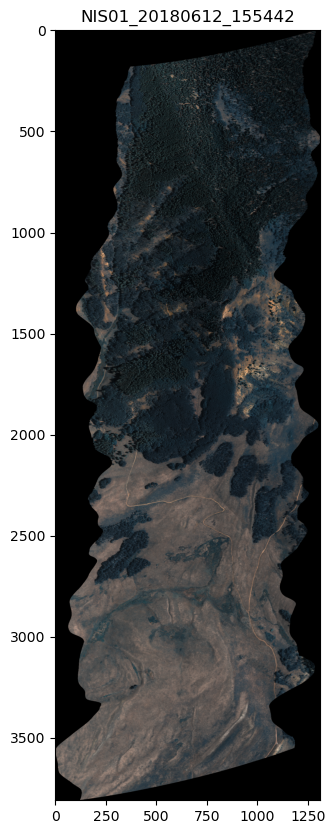

In [7]:
# rfl rgb for all flightlines

fig, ax = plt.subplots(figsize=(5,10))

working_dir = glob(os.path.join(home+f'{flight}*'))[0]
fp = glob(os.path.join(working_dir, 'output', f'{flight}_rfl.hdr'))[0]
rgb = envi.open(fp).open_memmap()[:,:,np.array([60,40,30])].copy()
ax.imshow(rgb / np.nanmax(rgb, axis=(0, 1)))
ax.set_title(flight)

plt.show()

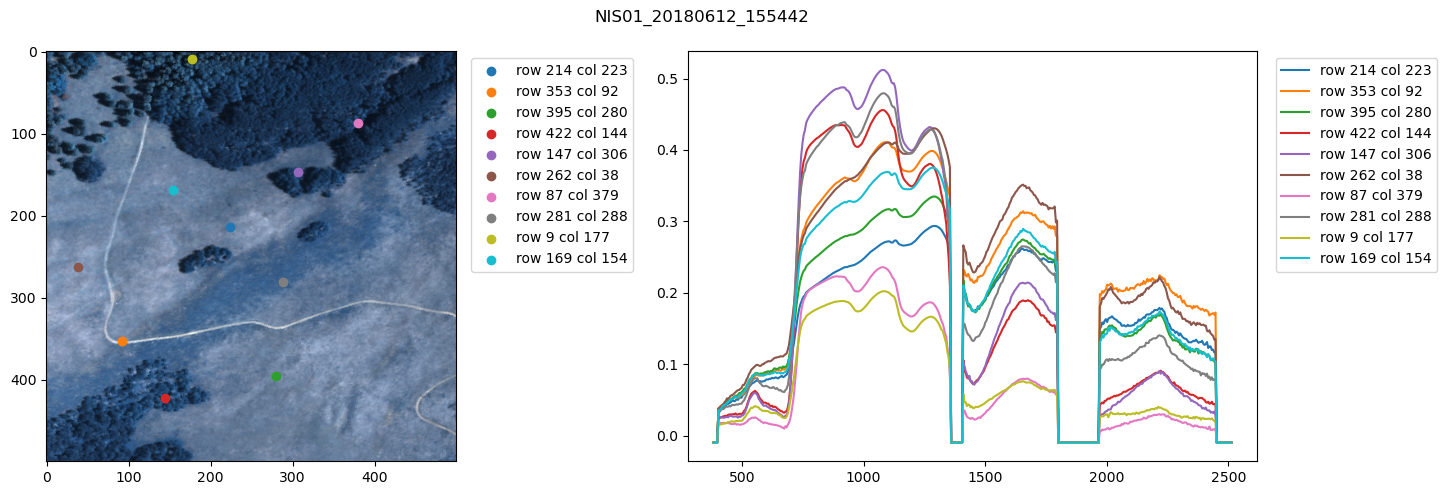

<Figure size 640x480 with 0 Axes>

In [14]:
# plot some spectra

working_dir = glob(os.path.join(home, f'{flight}'))[0]

size = 500
# row1 = 2000; col1 = 600
row1 = 2000; col1 = 280
# (2000, 50)

viz_rfl_subset(flight=flight, working_dir=working_dir, row1=row1, col1=col1, size=size, n_sample=10, wl=wl)

plt.savefig(os.path.join(out_figs, f'rfl_{flight}_row{row1}_col{col1}.png'), dpi=300)